# Profitable App Profiles for the App Store and Google Play Markets


   We're analysing for a company that builds Android and iOS mobile apps. We make our apps available on Google Play and the App Store.

   We only build apps that are free to download and install, and our main source of revenue consists of in-app ads. This means our revenue for any given app is mostly influenced by the number of users who use our app. Our goal for this project is to analyze data to help our developers understand what kinds of apps are likely to attract more users.

# Opening and Exploring the Data

In [1]:
import pandas as pd

apple_store = pd.read_csv("AppleStore.csv")
googlep_store = pd.read_csv("googleplaystore.csv")

In [2]:
apple_store.head()

,Unnamed: 0,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,1,281656475,PAC-MAN Premium,100788224,USD,3.99,21292,26,4.0,4.5,6.3.5,4+,Games,38,5,10,1
1,2,281796108,Evernote - stay organized,158578688,USD,0.00,161065,26,4.0,3.5,8.2.2,4+,Productivity,37,5,23,1
2,3,281940292,"WeatherBug - Local Weather, Radar, Maps, Alerts",100524032,USD,0.00,188583,2822,3.5,4.5,5.0.0,4+,Weather,37,5,3,1
3,4,282614216,"eBay: Best App to Buy, Sell, Save! Online Shop...",128512000,USD,0.00,262241,649,4.0,4.5,5.10.0,12+,Shopping,37,5,9,1
4,5,282935706,Bible,92774400,USD,0.00,985920,5320,4.5,5.0,7.5.1,4+,Reference,37,5,45,1


In [3]:
apple_store.shape

(7197, 17)

In [4]:
googlep_store.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [5]:
googlep_store.shape

(10841, 13)

In [6]:
googlep_store.dtypes

App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

# Removing redundant Columns

   
   
   We have 7197 iOS apps in this data set, and the columns that seem interesting are:
    'track_name', 'currency', 'price', 'rating_count_tot', 'rating_count_ver', and 'prime_genre'
    
    
    

In [7]:
apple_store1 = apple_store[['track_name', 'currency', 'price', 'rating_count_tot', 'user_rating','prime_genre']]
del apple_store
apple_store1.head()

,track_name,currency,price,rating_count_tot,user_rating,prime_genre
0,PAC-MAN Premium,USD,3.99,21292,4.0,Games
1,Evernote - stay organized,USD,0.00,161065,4.0,Productivity
2,"WeatherBug - Local Weather, Radar, Maps, Alerts",USD,0.00,188583,3.5,Weather
3,"eBay: Best App to Buy, Sell, Save! Online Shop...",USD,0.00,262241,4.0,Shopping
4,Bible,USD,0.00,985920,4.5,Reference




We see that the Google Play data set has 10841 apps and 13 columns. At a quick glance, the columns that might be useful for the purpose of our analysis are
'App', 'Category', 'Reviews', 'Installs', 'Type', 'Price', and 'Genres'.



In [8]:
googlep_store1 = googlep_store[['App','Reviews','Rating','Installs', 'Type', 'Price','Genres']]
del googlep_store
googlep_store1.head()

,App,Reviews,Rating,Installs,Type,Price,Genres
0,Photo Editor & Candy Camera & Grid & ScrapBook,159,4.1,"10,000+",Free,0,Art & Design
1,Coloring book moana,967,3.9,"500,000+",Free,0,Art & Design;Pretend Play
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",87510,4.7,"5,000,000+",Free,0,Art & Design
3,Sketch - Draw & Paint,215644,4.5,"50,000,000+",Free,0,Art & Design
4,Pixel Draw - Number Art Coloring Book,967,4.3,"100,000+",Free,0,Art & Design;Creativity


In [9]:
googlep_store1['App'].shape

(10841,)

# Data Cleaning 

## Google Store 

In [10]:
googlep_store1['App'].unique()

<StringArray>
[    'Photo Editor & Candy Camera & Grid & ScrapBook',
                                'Coloring book moana',
 'U Launcher Lite – FREE Live Cool Themes, Hide Apps',
                              'Sketch - Draw & Paint',
              'Pixel Draw - Number Art Coloring Book',
                         'Paper flowers instructions',
            'Smoke Effect Photo Maker - Smoke Editor',
                                   'Infinite Painter',
                               'Garden Coloring Book',
                      'Kids Paint Free - Drawing Fun',
 ...
                           'payermonstationnement.fr',
                                           'FR Tides',
                                        'Chemin (fr)',
                                      'FR Calculator',
                                           'FR Forms',
                                   'Sya9a Maroc - FR',
                   'Fr. Mike Schmitz Audio Teachings',
                             'Parkinson Exerci

In [11]:
googlep_store1['Reviews'].unique()

<StringArray>
[   '159',    '967',  '87510', '215644',    '167',    '178',  '36815',
  '13791',    '121',  '13880',
 ...
   '2036',  '56496', '376223',    '785',   '5775',    '885',  '88486',
    '603',   '1195', '398307']
Length: 6002, dtype: str

In [12]:
googlep_store1['Installs'].unique()

<StringArray>
[       '10,000+',       '500,000+',     '5,000,000+',    '50,000,000+',
       '100,000+',        '50,000+',     '1,000,000+',    '10,000,000+',
         '5,000+',   '100,000,000+', '1,000,000,000+',         '1,000+',
   '500,000,000+',            '50+',           '100+',           '500+',
            '10+',             '1+',             '5+',             '0+',
              '0',           'Free']
Length: 22, dtype: str

In [13]:
googlep_store1['Type'].unique()

<StringArray>
['Free', 'Paid', nan, '0']
Length: 4, dtype: str

In [14]:
googlep_store1['Price'].unique()

<StringArray>
[       '0',    '$4.99',    '$3.99',    '$6.99',    '$1.49',    '$2.99',
    '$7.99',    '$5.99',    '$3.49',    '$1.99',    '$9.99',    '$7.49',
    '$0.99',    '$9.00',    '$5.49',   '$10.00',   '$24.99',   '$11.99',
   '$79.99',   '$16.99',   '$14.99',    '$1.00',   '$29.99',   '$12.99',
    '$2.49',   '$10.99',    '$1.50',   '$19.99',   '$15.99',   '$33.99',
   '$74.99',   '$39.99',    '$3.95',    '$4.49',    '$1.70',    '$8.99',
    '$2.00',    '$3.88',   '$25.99',  '$399.99',   '$17.99',  '$400.00',
    '$3.02',    '$1.76',    '$4.84',    '$4.77',    '$1.61',    '$2.50',
    '$1.59',    '$6.49',    '$1.29',    '$5.00',   '$13.99',  '$299.99',
  '$379.99',   '$37.99',   '$18.99',  '$389.99',   '$19.90',    '$8.49',
    '$1.75',   '$14.00',    '$4.85',   '$46.99',  '$109.99',  '$154.99',
    '$3.08',    '$2.59',    '$4.80',    '$1.96',   '$19.40',    '$3.90',
    '$4.59',   '$15.46',    '$3.04',    '$4.29',    '$2.60',    '$3.28',
    '$4.60',   '$28.99',    '$2.95', 

In [15]:
googlep_store1['Genres'].unique()

<StringArray>
[                   'Art & Design',       'Art & Design;Pretend Play',
         'Art & Design;Creativity', 'Art & Design;Action & Adventure',
                 'Auto & Vehicles',                          'Beauty',
               'Books & Reference',                        'Business',
                          'Comics',               'Comics;Creativity',
 ...
    'Books & Reference;Creativity',     'Books & Reference;Education',
                'Puzzle;Education',          'Role Playing;Education',
        'Role Playing;Brain Games',              'Strategy;Education',
             'Racing;Pretend Play',        'Communication;Creativity',
               'February 11, 2018',             'Strategy;Creativity']
Length: 120, dtype: str

# Google Store Data Report :
1.Install column is not an exact number. It contains buckets such 10,000+ . So Create a numeric lower-bound column:
'Install_Lower_Bound'                
2.Rating column has vaue  19.It cannot be valid because ratings should be between 0 and 5.                   
3.Dataset also has duplicates and missing values             
4.Convert reviews to numeric type

In [16]:

# -------------------------------
# Convert Rating
# -------------------------------

googlep_store1["Rating"] = pd.to_numeric(
    googlep_store1["Rating"],
    errors="coerce"
)

# Remove invalid rating records
googlep_store1 = googlep_store1[
    googlep_store1["Rating"].isna() |
    googlep_store1["Rating"].between(0, 5)
]

# -------------------------------
# Convert Reviews
# -------------------------------

googlep_store1["Reviews"] = pd.to_numeric(
    googlep_store1["Reviews"],
    errors="coerce"
)

# -------------------------------
# Convert Installs
# -------------------------------

googlep_store1["Install_Lower_Bound"] = (
    googlep_store1["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

googlep_store1 = googlep_store1.drop("Installs",axis=1)
googlep_store1["Install_Lower_Bound"] = pd.to_numeric(
    googlep_store1["Install_Lower_Bound"],
    errors="coerce"
)

# -------------------------------
# Remove missing values
# -------------------------------

googlep_store1 = googlep_store1.dropna(
    subset=["App", "Genres", "Install_Lower_Bound"]
)

# -------------------------------
# Remove duplicate apps
# -------------------------------

googlep_store1 = (
    googlep_store1.sort_values("Reviews", ascending=False)
      .drop_duplicates("App")
)

#---------------------------
# Change the price type
#--------------------------


googlep_store1["Price"]=  (googlep_store1["Price"].str.replace("$", "", regex=False))
googlep_store1["Genres"]=  googlep_store1["Genres"].str.split(';').str[0]

In [17]:
googlep_store1.head()

,App,Reviews,Rating,Type,Price,Genres,Install_Lower_Bound
2544,Facebook,78158306,4.1,Free,0,Social,1000000000
381,WhatsApp Messenger,69119316,4.4,Free,0,Communication,1000000000
2604,Instagram,66577446,4.5,Free,0,Social,1000000000
382,Messenger – Text and Video Chat for Free,56646578,4.0,Free,0,Communication,1000000000
1879,Clash of Clans,44893888,4.6,Free,0,Strategy,100000000


In [18]:
googlep_store1["Price"].values

<StringArray>
[   '0',    '0',    '0',    '0',    '0',    '0',    '0',    '0',    '0',
    '0',
 ...
    '0',    '0',    '0',    '0',    '0',    '0',    '0', '0.99', '0.99',
    '0']
Length: 9659, dtype: str

## Apple Store

In [19]:
apple_store1.head(2)

,track_name,currency,price,rating_count_tot,user_rating,prime_genre
0,PAC-MAN Premium,USD,3.99,21292,4.0,Games
1,Evernote - stay organized,USD,0.00,161065,4.0,Productivity


In [20]:
apple_store1['track_name'].unique()

<StringArray>
[                                   'PAC-MAN Premium',
                          'Evernote - stay organized',
    'WeatherBug - Local Weather, Radar, Maps, Alerts',
 'eBay: Best App to Buy, Sell, Save! Online Shopping',
                                              'Bible',
                                   'Shanghai Mahjong',
             'PayPal - Send and request money safely',
                            'Pandora - Music & Radio',
                        'PCalc - The Best Calculator',
                                        'Ms. PAC-MAN',
 ...
                          'Escape Game: illumination',
       'Demolition Derby Virtual Reality (VR) Racing',
                         '飞刀传奇-动作武侠热血江湖即时PK传奇（登录爆金装）',
                       'Add-Ons Studio for Minecraft',
                         'Plead the Fifth - The Game',
                                              'Kubik',
                                  'VR Roller-Coaster',
              'Bret Michaels Emojis + Lyric Ke

In [21]:
apple_store1['price'].unique()

array([  3.99,   0.  ,   0.99,   9.99,   4.99,   7.99,   2.99,   1.99,
         5.99,  12.99,  21.99, 249.99,   6.99,  74.99,  19.99,   8.99,
        24.99,  13.99,  14.99,  16.99,  47.99,  11.99,  59.99,  15.99,
        27.99,  17.99, 299.99,  49.99,  23.99,  20.99,  39.99,  99.99,
        29.99,  34.99,  18.99,  22.99])

In [22]:
apple_store1['rating_count_tot'].unique()

array([ 21292, 161065, 188583, ...,    283,   3384,   1441],
      shape=(3185,), dtype=int64)

In [23]:
apple_store1['user_rating'].unique()

array([4. , 3.5, 4.5, 5. , 3. , 2. , 2.5, 0. , 1.5, 1. ])

In [24]:
apple_store1[apple_store1['user_rating'] < 0]

,track_name,currency,price,rating_count_tot,user_rating,prime_genre


In [25]:
apple_store1['prime_genre'].unique()

<StringArray>
[            'Games',      'Productivity',           'Weather',
          'Shopping',         'Reference',           'Finance',
             'Music',         'Utilities',            'Travel',
 'Social Networking',            'Sports',          'Business',
  'Health & Fitness',     'Entertainment',     'Photo & Video',
        'Navigation',         'Education',         'Lifestyle',
      'Food & Drink',              'News',              'Book',
           'Medical',          'Catalogs']
Length: 23, dtype: str

# Apple Store Data Report




1. The company  builds apps that are free to download and install, and that are directed toward an English-speaking audience. This means that we'll need to:

* Remove non-English apps like 爱奇艺PPS -《欢乐颂2》电视剧热播
* Remove non-free apps
2. Removing duplicates
3. Creating a column to determine whether its free or paid app

In [26]:

for row in apple_store1["track_name"]:  
    for char in row:
        if len(str(ord(char))) == 5: 
            apple_store1 = apple_store1[apple_store1["track_name"]!= row]
            break    

In [27]:
apple_store1["track_name"].value_counts().head()


track_name
VR Roller Coaster                                  2
Mannequin Challenge                                2
PAC-MAN Premium                                    1
Evernote - stay organized                          1
WeatherBug - Local Weather, Radar, Maps, Alerts    1
Name: count, dtype: int64

# Track_name Cleaning 

In [28]:
apple_store1["track_name"] = (
    apple_store1["track_name"]
    .str.replace(r"^[^\w\s()]+", "", regex=True)
    .str.strip()
)
apple_store1["track_name"].values

<StringArray>
[                                   'PAC-MAN Premium',
                          'Evernote - stay organized',
    'WeatherBug - Local Weather, Radar, Maps, Alerts',
 'eBay: Best App to Buy, Sell, Save! Online Shopping',
                                              'Bible',
                                   'Shanghai Mahjong',
             'PayPal - Send and request money safely',
                            'Pandora - Music & Radio',
                        'PCalc - The Best Calculator',
                                        'Ms. PAC-MAN',
 ...
                                    'Survivalcraft 2',
                          'Escape Game: illumination',
       'Demolition Derby Virtual Reality (VR) Racing',
                       'Add-Ons Studio for Minecraft',
                         'Plead the Fifth - The Game',
                                              'Kubik',
                                  'VR Roller-Coaster',
              'Bret Michaels Emojis + Lyric Ke

# Deleting the duplicates

 The apple store data has 2 duplicates .We are deleting the duplicates by taking the values which has 
    the highest count of reviews since it will be the recent review

In [29]:
apple_store1["track_name"].shape

(6133,)

In [30]:
apple_store1["track_name"].unique().shape

(6129,)

In [31]:
apple_store1["track_name"].value_counts()

track_name
Solitaire                                    3
VR Roller Coaster                            2
Mannequin Challenge                          2
PAC-MAN Premium                              1
Evernote - stay organized                    1
                                            ..
Kubik                                        1
VR Roller-Coaster                            1
Bret Michaels Emojis + Lyric Keyboard        1
VR Roller Coaster World - Virtual Reality    1
Escape the Sweet Shop Series                 1
Name: count, Length: 6129, dtype: int64

In [32]:
apple_store1[apple_store1["track_name"] == "VR Roller Coaster"]


,track_name,currency,price,rating_count_tot,user_rating,prime_genre
3319,VR Roller Coaster,USD,0.0,107,3.5,Games
5603,VR Roller Coaster,USD,0.0,67,3.5,Games


In [33]:
apple_store1[apple_store1["track_name"] == "Mannequin Challenge"]

,track_name,currency,price,rating_count_tot,user_rating,prime_genre
7092,Mannequin Challenge,USD,0.0,668,3.0,Games
7128,Mannequin Challenge,USD,0.0,105,4.0,Games


In [34]:
apple_store1 = (
    apple_store1.sort_values(
        ["track_name", "rating_count_tot"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset=["track_name"],
        keep="first"
    )
    .reset_index(drop=True)
)

In [35]:
apple_store1["track_name"].shape

(6129,)

In [36]:
apple_store1["track_name"].value_counts()

track_name
( OFFTIME ) light – Track how much you use your phone & Digital Detox and unplug to focus    1
) Sudoku +                                                                                   1
1 Second Everyday: Video Diary                                                               1
1+2=3                                                                                        1
1-Bit Rogue: A dungeon crawler RPG!                                                          1
                                                                                            ..
wetter.com                                                                                   1
ytools-flashlight,ruler,spirit level,protractor and sound level meter                        1
Übungen für einen starken Rücken – GEO WISSEN GESUNDHEIT                                     1
Сluster Traffic: Parkour Trucks Pro                                                          1
لغز الماضي - اربع اجزاء                

In [37]:
apple_store1["track_name"].unique().shape

(6129,)

# Creating App type column

In [38]:
import numpy as np

apple_store1["Type"] = np.where(
    apple_store1["price"] == 0,
    "Free",
    "Paid"
)

apple_store1 = apple_store1.drop("currency",axis=1)

In [39]:
apple_store1

,track_name,price,rating_count_tot,user_rating,prime_genre,Type
0,( OFFTIME ) light – Track how much you use you...,2.99,22,2.0,Health & Fitness,Paid
1,) Sudoku +,2.99,11447,5.0,Games,Paid
2,1 Second Everyday: Video Diary,4.99,2433,3.5,Photo & Video,Paid
3,1+2=3,0.00,2816,4.0,Games,Free
4,1-Bit Rogue: A dungeon crawler RPG!,0.00,378,4.5,Games,Free
...,...,...,...,...,...,...
6124,wetter.com,0.00,0,0.0,Weather,Free
6125,"ytools-flashlight,ruler,spirit level,protracto...",0.99,43,4.5,Utilities,Paid
6126,Übungen für einen starken Rücken – GEO WISSEN ...,1.99,0,0.0,Health & Fitness,Paid
6127,Сluster Traffic: Parkour Trucks Pro,0.99,4,3.5,Games,Paid


# Exploratory Data Analysis

# Google Play store

# Relationship Analysis               
   ├── Google: Installs ↔ Reviews        
   ├── Google: Installs ↔ Rating                   
   └── Apple: Ratings ↔ Engagement

In [40]:
free_apps = googlep_store1[
    googlep_store1["Type"] == "Free"
].copy()


In [41]:
numeric_cols = [
    "Reviews",
    "Rating",
    "Price",
    "Install_Lower_Bound"
]

correlation = free_apps[numeric_cols].corr()

print(correlation)

                      Reviews    Rating  Price  Install_Lower_Bound
Reviews              1.000000  0.059088    NaN             0.624593
Rating               0.059088  1.000000    NaN             0.044119
Price                     NaN       NaN    NaN                  NaN
Install_Lower_Bound  0.624593  0.044119    NaN             1.000000


# Reviews vs Installations ⭐

### Do apps with more installations tend to receive more reviews?

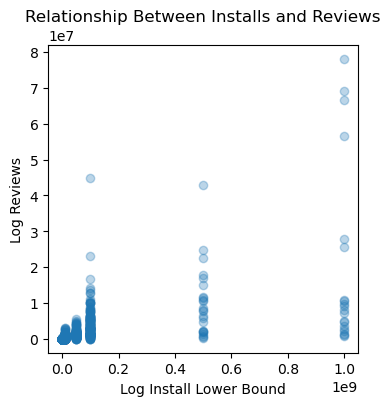

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))

plt.scatter(
    free_apps["Install_Lower_Bound"],
    free_apps["Reviews"],
    alpha=0.3
)

plt.xlabel("Log Install Lower Bound")
plt.ylabel("Log Reviews")
plt.title("Relationship Between Installs and Reviews")

plt.show()

# Rating vs Installations

## Do highly rated apps attract more installs?

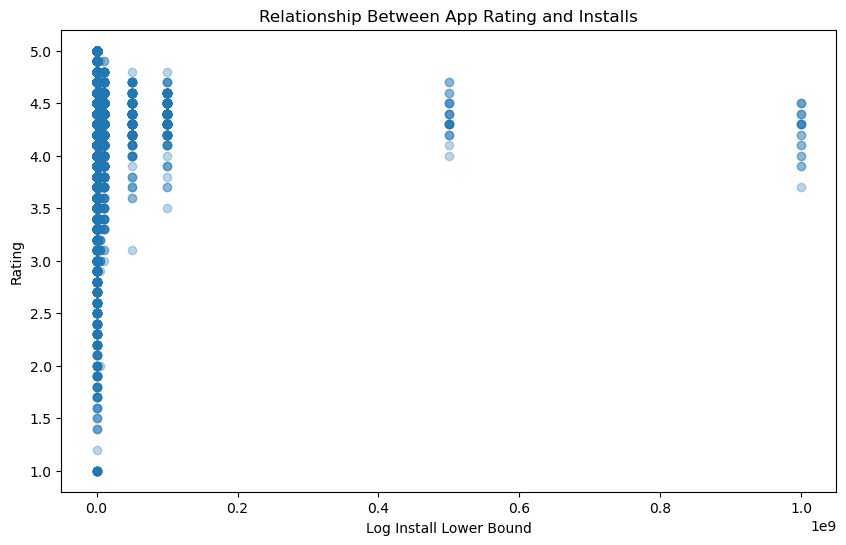

In [43]:
plt.figure(figsize=(10, 6))

plt.scatter(
    free_apps["Install_Lower_Bound"],
    free_apps["Rating"],
    alpha=0.3
)

plt.xlabel("Log Install Lower Bound")
plt.ylabel("Rating")
plt.title("Relationship Between App Rating and Installs")

plt.show()

# Price vs Rating

## Does app price have any relationship with user rating?

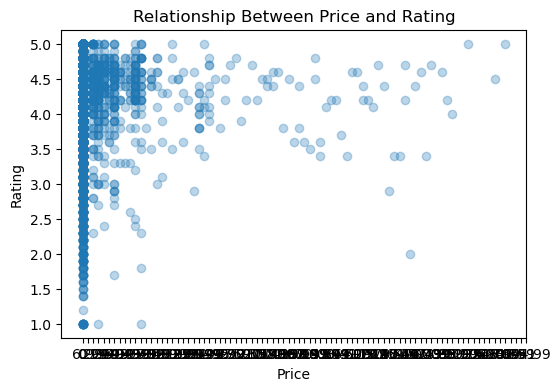

In [44]:
plt.figure(figsize=(6, 4))

plt.scatter(
    googlep_store1["Price"],
    googlep_store1["Rating"],
    alpha=0.3
)

plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Relationship Between Price and Rating")

plt.show()

# Do paid apps receive different ratings?

In [45]:
googlep_store1.groupby("Type")["Rating"].mean()

Type
Free    4.166223
Paid    4.262126
Name: Rating, dtype: float64

# Which genres have stronger user satisfaction?

In [46]:
genre_rating = (
    free_apps
    .groupby("Genres")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print(genre_rating.head(15))

Genres
Events               4.435556
Puzzle               4.353846
Books & Reference    4.344444
Parenting            4.339583
Art & Design         4.330508
Word                 4.318182
Personalization      4.300000
Music & Audio        4.300000
Education            4.294348
Beauty               4.278571
Casino               4.277778
Role Playing         4.276136
Arcade               4.275758
Board                4.253659
Social               4.252736
Name: Rating, dtype: float64


# Which genres have the strongest audience potential?

In [47]:
free_apps["Genres"] = free_apps["Genres"].str.split(';').str[0]

In [48]:
genre_installs = (
    free_apps
    .groupby("Genres")["Install_Lower_Bound"]
    .sum()
    .sort_values(ascending=False)
)

print(genre_installs.head(15))

Genres
Communication              11037416201
Tools                       8101044474
Productivity                5791679314
Social                      5487861902
Photography                 4656268915
Video Players & Editors     3936831720
Arcade                      3789791941
Action                      3518986940
Casual                      3415009570
Entertainment               3159872513
Travel & Local              2894704086
News & Magazines            2369212260
Books & Reference           1665947260
Racing                      1533386820
Personalization             1529235988
Name: Install_Lower_Bound, dtype: int64


# Apple App Store EDA

Apple Store
Installations       → NOT available                 
rating_count_tot    → rating/engagement proxy                      
We’ll use rating_count_tot consistently as the engagement/popularity measure.
Since ,business requirement is free apps for an English-speaking audience,let us start with the filtered Apple dataset.

In [49]:
apple_eda = apple_store1[
    (apple_store1["Type"] == "Free")
].copy()

print("Total English + Free apps:", len(apple_eda))

Total English + Free apps: 3177


In [50]:
apple_eda.head(2)

,track_name,price,rating_count_tot,user_rating,prime_genre,Type
3,1+2=3,0.0,2816,4.0,Games,Free
4,1-Bit Rogue: A dungeon crawler RPG!,0.0,378,4.5,Games,Free


In [51]:
apple_eda[
        ["rating_count_tot", "user_rating"]
    ].describe()

,rating_count_tot,user_rating
count,3.177000e+03,3177.000000
mean,2.504675e+04,3.889833
std,1.097948e+05,1.054698
min,0.000000e+00,0.000000
25%,1.470000e+02,3.500000
50%,1.221000e+03,4.000000
75%,1.010700e+04,4.500000
max,2.974676e+06,5.000000


# Number of free apps by genre


## Which genres have the most free apps?

In [52]:
genre_count = (
    apple_eda["prime_genre"]
    .value_counts()
)

print(genre_count.head(15))

prime_genre
Games                1856
Entertainment         252
Photo & Video         159
Education             117
Social Networking     104
Shopping               80
Utilities              76
Sports                 69
Health & Fitness       65
Music                  65
Productivity           53
Lifestyle              49
News                   43
Travel                 38
Finance                35
Name: count, dtype: int64


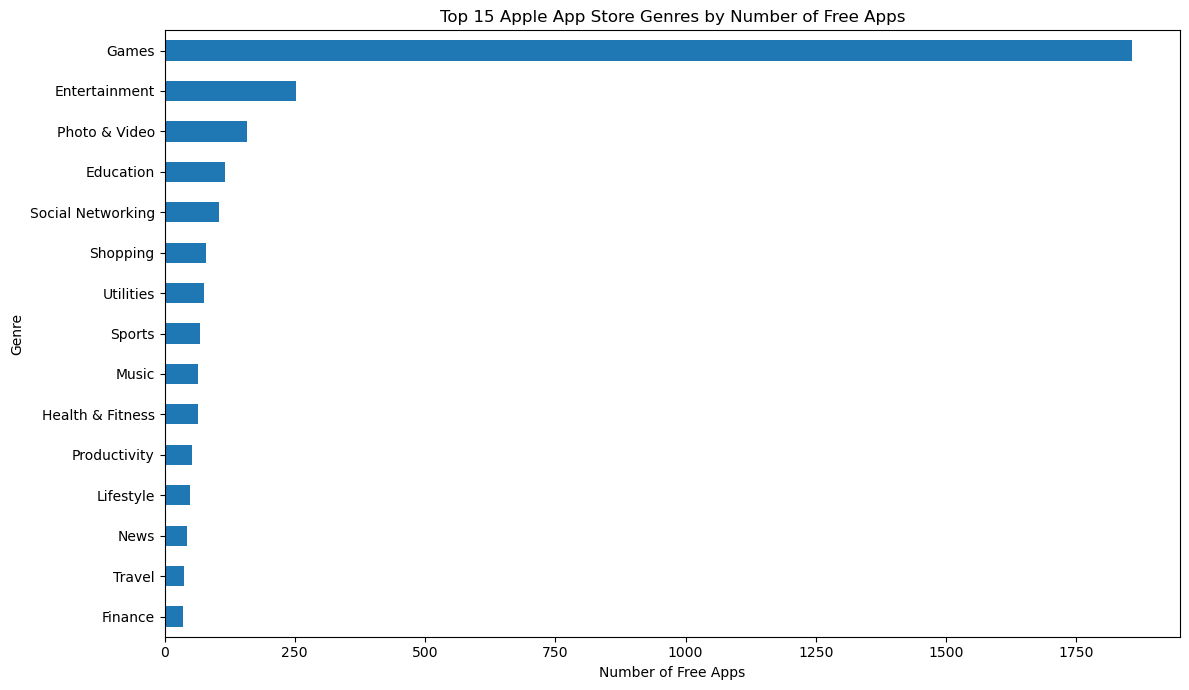

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

genre_count.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 15 Apple App Store Genres by Number of Free Apps"
)

plt.xlabel("Number of Free Apps")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

# Total ratings by genre

## Which Apple genres have the highest user engagement?

In [54]:
rating_count_by_genre = (
    apple_eda
    .groupby("prime_genre")["rating_count_tot"]
    .sum()
    .sort_values(ascending=False)
)

print(
    rating_count_by_genre.head(15)
)

prime_genre
Games                42470417
Social Networking     7583321
Photo & Video         4550487
Music                 3783327
Entertainment         3563136
Shopping              2259035
Sports                1587614
Health & Fitness      1514371
Utilities             1477258
Weather               1463837
Reference             1348958
Productivity          1165092
Finance               1132846
Travel                1129421
News                   913665
Name: rating_count_tot, dtype: int64


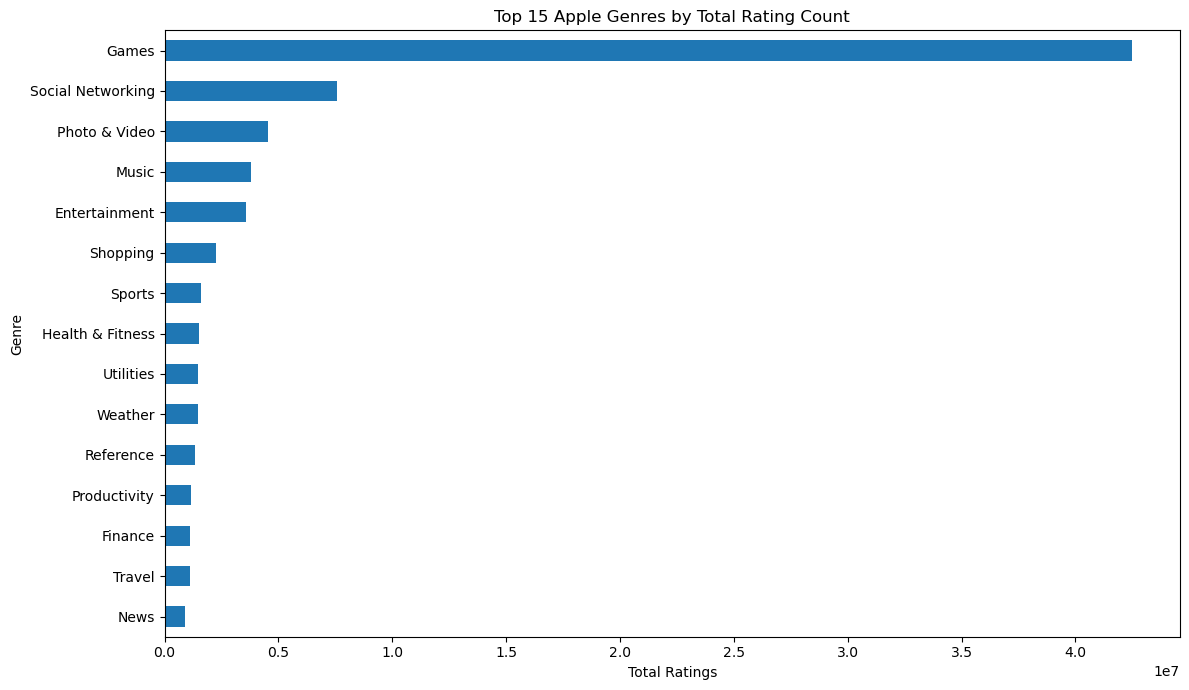

In [55]:
plt.figure(figsize=(12, 7))

rating_count_by_genre.head(15).sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 15 Apple Genres by Total Rating Count"
)

plt.xlabel("Total Ratings")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [56]:
genre_rating = (
    apple_eda
    .groupby("prime_genre")
    .agg(
        app_count=("track_name", "count"),
        average_rating=("user_rating", "mean")
    )
)

genre_rating = genre_rating[
    genre_rating["app_count"] >= 10
].sort_values(
    "average_rating",
    ascending=False
)

print(
    genre_rating.head(15).round(2)
)

                   app_count  average_rating
prime_genre                                 
Games                   1856            4.06
Productivity              53            4.06
Business                  17            3.97
Shopping                  80            3.96
Music                     65            3.95
Photo & Video            159            3.90
Reference                 17            3.88
Health & Fitness          65            3.77
Education                117            3.64
Food & Drink              26            3.63
Social Networking        104            3.60
Book                      12            3.58
Utilities                 76            3.57
Entertainment            252            3.55
Travel                    38            3.51


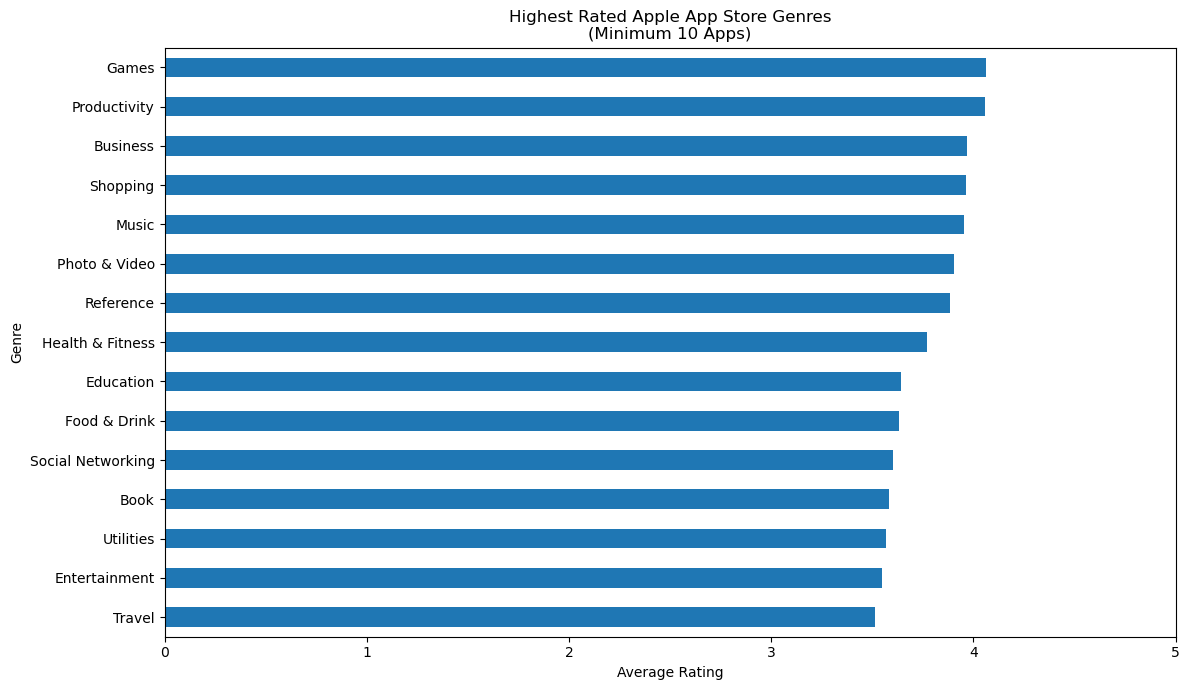

In [57]:
plt.figure(figsize=(12, 7))

genre_rating.head(15)[
    "average_rating"
].sort_values().plot(
    kind="barh"
)

plt.title(
    "Highest Rated Apple App Store Genres\n(Minimum 10 Apps)"
)

plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [58]:
correlation = apple_eda[[
        "rating_count_tot",
        "user_rating"
    ]
].corr()

print(correlation)

                  rating_count_tot  user_rating
rating_count_tot          1.000000     0.078118
user_rating               0.078118     1.000000


# Comparison between Apple and Google

## Rename Google column so both tables have a common category column

In [59]:
apple_eda.head(1)

,track_name,price,rating_count_tot,user_rating,prime_genre,Type
3,1+2=3,0.0,2816,4.0,Games,Free


In [60]:
apple_eda = apple_eda.rename(
    columns={"prime_genre": "Genre","user_rating":"Rating","track_name":"App"}
)
apple_eda.head(1)

,App,price,rating_count_tot,Rating,Genre,Type
3,1+2=3,0.0,2816,4.0,Games,Free


In [61]:
apple_eda.groupby("Genre").agg(
        Apple_Rating_Count=("rating_count_tot", "sum")).sort_values(by="Apple_Rating_Count").tail(2)

,Apple_Rating_Count
Genre,
Social Networking,7583321
Games,42470417


In [62]:
googlep_store1.head(1)

,App,Reviews,Rating,Type,Price,Genres,Install_Lower_Bound
2544,Facebook,78158306,4.1,Free,0,Social,1000000000


In [63]:
googlep_store1 = googlep_store1.rename(
    columns={"Genres": "Genre","Install_Lower_Bound":"Google_Installation","Reviews":"Google_Reviews"}
)
googlep_store1.head(1)

,App,Google_Reviews,Rating,Type,Price,Genre,Google_Installation
2544,Facebook,78158306,4.1,Free,0,Social,1000000000


# Comparison

In [64]:
import pandas as pd
import matplotlib.pyplot as plt


# Combine both datasets
comparison = pd.merge(
    apple_eda,
    googlep_store1,
    on="Genre",
    how="outer",
    suffixes=("_Apple", "_Google")
).fillna(0)

comparison.head(2)

,App_Apple,price,rating_count_tot,Rating_Apple,Genre,Type_Apple,App_Google,Google_Reviews,Rating_Google,Type_Google,Price,Google_Installation
0,0,0.0,0.0,0.0,Action,0,Shadow Fight 2,10981850.0,4.6,Free,0,100000000.0
1,0,0.0,0.0,0.0,Action,0,Mobile Legends: Bang Bang,8219586.0,4.4,Free,0,100000000.0


In [65]:
comparison = comparison.drop(columns=["price","Price","Type_Google","Type_Apple","rating_count_tot"])
comparison.head(2)

,App_Apple,Rating_Apple,Genre,App_Google,Google_Reviews,Rating_Google,Google_Installation
0,0,0.0,Action,Shadow Fight 2,10981850.0,4.6,100000000.0
1,0,0.0,Action,Mobile Legends: Bang Bang,8219586.0,4.4,100000000.0


In [66]:
comparison = comparison[["Genre","App_Google","App_Apple","Rating_Google","Rating_Apple","Google_Installation","Google_Reviews"]]


In [67]:
comparison["Genre"] = comparison["Genre"].str.title()
summary = (
    comparison
    .groupby("Genre")
    .agg(
        Google_Installation=("Google_Installation", "sum"),
        Google_rating=("Rating_Google", "mean"),
        Apple_rating=("Rating_Apple", "mean")
    )
    .reset_index()
)
summary.head(10)

,Genre,Google_Installation,Google_rating,Apple_rating
0,Action,3.536060e+09,4.152090,0.000000
1,Adventure,4.129453e+08,4.086250,0.000000
2,Arcade,3.801339e+09,3.976884,0.000000
3,Art & Design,1.148381e+08,4.149231,0.000000
4,Auto & Vehicles,5.313021e+07,3.598824,0.000000
5,Beauty,2.719705e+07,3.390566,0.000000
6,Board,1.709144e+08,4.076667,0.000000
7,Book,0.000000e+00,0.000000,3.583333
8,Books & Reference,1.665981e+09,3.300889,0.000000
9,Business,1.185180e+10,2.566429,3.970588


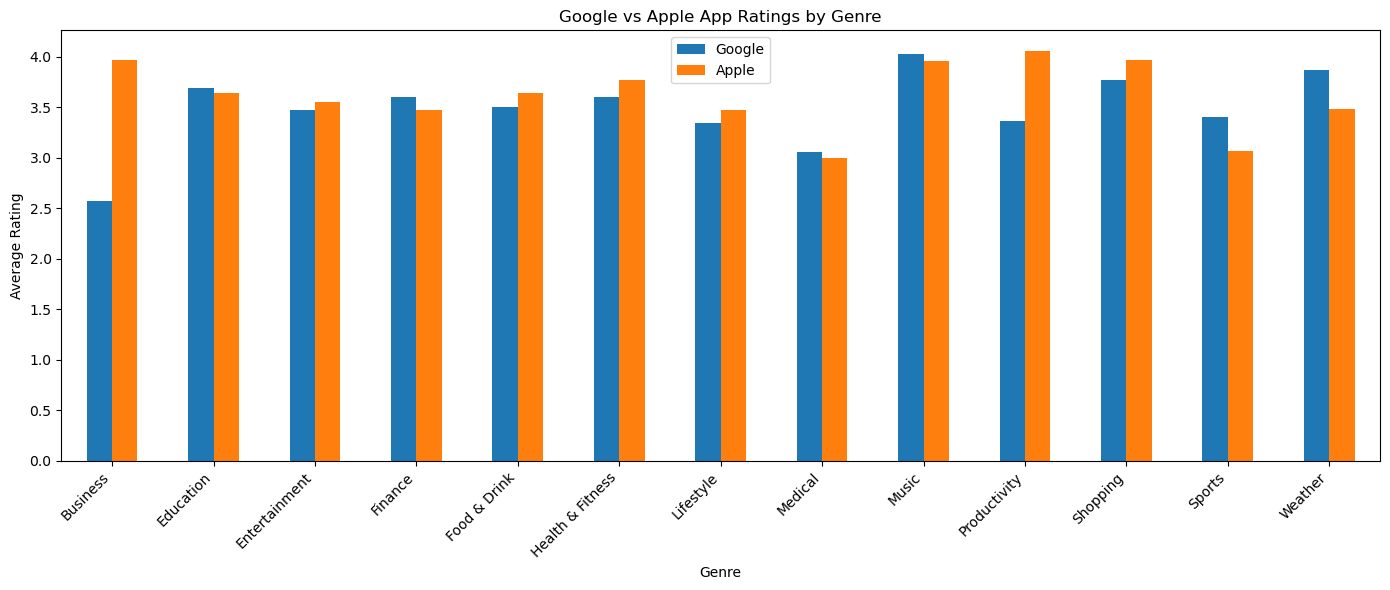

In [68]:
common = summary[
    (summary["Google_rating"] > 0) &
    (summary["Apple_rating"] > 0)
].copy()

common.plot(
    x="Genre",
    y=["Google_rating", "Apple_rating"],
    kind="bar",
    figsize=(14, 6)
)

plt.title("Google vs Apple App Ratings by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.legend(["Google", "Apple"])
plt.tight_layout()
plt.show()

Interesting insights
1. Entertainment dominates Google ,           
Entertainment has around 760B installations, much higher than most other categories.        
Rating : 3.42  ⭐
3. Productivity is extremely strong                                   
Google has around 307B installs, while Apple has around 436M ratings. More importantly, Apple has a much higher average rating:
Apple: 4.06 ⭐ vs Google: 3.37 ⭐
4. Shopping is strong on both platforms                    
Google:
112B installs
Apple:
4.56×10⁸ ratings (~456M)
Ratings are also quite good:
Apple 3.96 ⭐ vs Google 3.77 ⭐
5. Sports is interesting                
Google rating:
3.39 ⭐
Apple rating:
3.06 ⭐
So Google has the higher rating here.
6. Music is almost identical                 
Google:
3.95 ⭐
Apple:3.94 ⭐


In [69]:
comparison.head(2)

,Genre,App_Google,App_Apple,Rating_Google,Rating_Apple,Google_Installation,Google_Reviews
0,Action,Shadow Fight 2,0,4.6,0.0,100000000.0,10981850.0
1,Action,Mobile Legends: Bang Bang,0,4.4,0.0,100000000.0,8219586.0


Messaging Applications has the most installations in Google store.B This number is heavily skewed up by a few apps that have over one billion installs (WhatsApp, Facebook Messenger, Skype, Google Chrome, Gmail, and Hangouts), and a few others with over 100 and 500 million installs:

# Part two

In [ ]:
apple_store1.groupby("prime_genre")["rating_count_tot"].sum().sort_values(ascending=False).head(25)

In [ ]:
((apple_store1["prime_genre"].value_counts(normalize = True))*100).head(10)

58% of the applications in Apple store are Games .The general impression is that App Store (at least the part containing free English apps) is dominated by apps that are designed for fun (games, entertainment, photo and video, social networking, sports, music, etc.), while apps with practical purposes (education, shopping, utilities, productivity, lifestyle, etc.) are more rare. 
However, the fact that fun apps are the most numerous doesn't also imply that they also have the greatest number of users — the demand might not be the same as the offer.
For example,Weather Application has the higher number of reviews.But Apple has less weather applications

In [ ]:
apple_store1[apple_store1["prime_genre"] == "Social Networking"].head(10)

# Result:

The applications(Games,Social Networking,Photo & Video,Music,Entertainment)
which has the highest number of reviews are dominated by big players like Facebook ,linkedin etc . 
And the other app with higher reviews require indepth domain knowledge . 
The app 'Books' seems to be interesting since it has higher reviews

In [ ]:
googlep_store2.loc[googlep_store2["Genres"] == "Books & Reference","App"].head(10)

There are less number of applications with the BOOKS genre in google and apple store.
Book has good user base(556619) in Apple store and it has higher reviews in google store too.It is free and it doesn't require in-depth domain knowledge